In [1]:
!pip install jax jaxlib matplotlib

#Part 1: Measuring Compilation Overhead

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
def fn_ops(x):
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x)
    x = jnp.log(x + 1)
    x = jnp.square(x)
    x = jnp.sqrt(x + 1)
    x = jnp.tanh(x)
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x)
    return x

jit_ops = jax.jit(fn_ops)



In [4]:
sizes = [100, 500, 1000, 5000]

eager_times = []
jit_first_times = []
jit_second_times = []

for n in sizes:
    x = jnp.ones((n, n))
    start = time.time()
    fn_ops(x).block_until_ready()
    eager_times.append(time.time() - start)
    start = time.time()
    jit_ops(x).block_until_ready()
    jit_first_times.append(time.time() - start)
    start = time.time()
    jit_ops(x).block_until_ready()
    jit_second_times.append(time.time() - start)






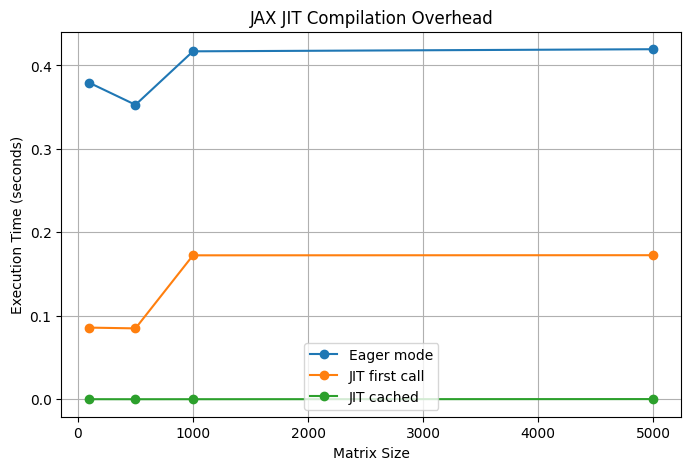

In [5]:
plt.figure(figsize=(8,5))

plt.plot(sizes, eager_times, marker='o', label="Eager mode")
plt.plot(sizes, jit_first_times, marker='o', label="JIT first call")
plt.plot(sizes, jit_second_times, marker='o', label="JIT cached")

plt.xlabel("Matrix Size")
plt.ylabel("Execution Time (seconds)")
plt.title("JAX JIT Compilation Overhead")
plt.legend()
plt.grid(True)

plt.show()

The plot shows the execution time of three cases: eager execution, the first JIT call, and the cached JIT call for different matrix sizes.

Eager execution runs the function normally without compilation. Because each operation is executed separately, it usually takes longer than the optimised compiled version.

The first JIT call includes the compilation time. When the function is called for the first time, JAX traces the function and compiles it using XLA. This additional compilation step increases the execution time.

The second JIT call reuses the compiled version of the function. Since the compiled code is already cached, only the actual computation is executed. Therefore the cached JIT execution is the fastest.

As the matrix size increases, the computation becomes larger and the benefit of JIT compilation becomes more visible. For large inputs the compiled version performs the operations more efficiently than eager execution.

#Part 2 — Shape Specialisation

In [6]:
@jax.jit
def fn2(x):
    return jnp.mean(x, axis=1)

In [7]:
shapes = [
    (100,100),
    (100,200),
    (100,100),
    (200,100)
]

times = []

for shape in shapes:

    x = jnp.ones(shape)

    start = time.time()
    fn2(x).block_until_ready()
    times.append(time.time() - start)


In [8]:
x = jnp.ones((100,100))
print(jax.make_jaxpr(fn2)(x))

x = jnp.ones((100,200))
print(jax.make_jaxpr(fn2)(x))


{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=fn2
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }
{ lambda ; a:f32[100,200]. let
    b:f32[100] = jit[
      name=fn2
      jaxpr={ lambda ; a:f32[100,200]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 200.0:f32[]
        in (b,) }
    ] a
  in (b,) }


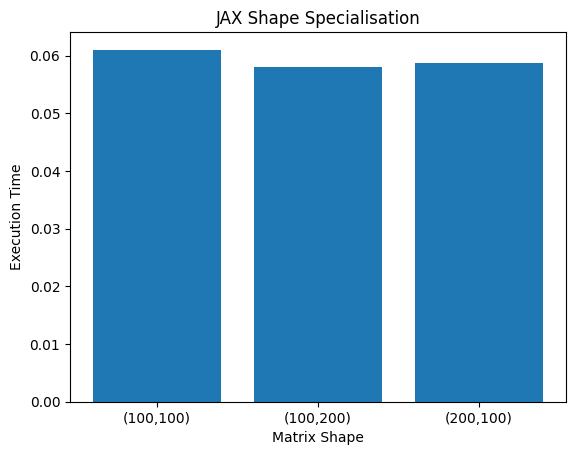

In [9]:
labels = ["(100,100)", "(100,200)", "(100,100)", "(200,100)"]

plt.bar(labels, times)

plt.xlabel("Matrix Shape")
plt.ylabel("Execution Time")
plt.title("JAX Shape Specialisation")

plt.show()


This experiment shows how JAX specialises compiled functions for different input shapes.

When the JIT compiled function is called with a particular shape, JAX creates a compiled version that is specialised for that shape. If the function is called again with the same shape, the cached compiled version is reused.

When a new input shape is used, JAX retraces and recompiles the function. This retracing step introduces additional overhead.

In the plot we see small differences in execution time because each new shape requires recompilation. Once the shape has already been compiled, later executions are faster because the compiled version is reused.

# Part 3 — Operator Fusion

In [3]:

def apply_sin_i(x, i):
    y = x
    for _ in range(i):
        y = jnp.sin(y)
    return y

def apply_cos_i(x, i):
    y = x
    for _ in range(i):
        y = jnp.cos(y)
    return y

def fn_eager(x):
    result = jnp.zeros_like(x)

    for i in range(1, 101):
        sin_part = apply_sin_i(x, i)
        cos_part = apply_cos_i(x, i)
        result = result + (sin_part + cos_part)

    return result


In [4]:
@jax.jit
def fn_jit(x):
    result = jnp.zeros_like(x)
    for i in range(1, 101):
        y = x
        for _ in range(i):
            y = jnp.sin(y)
        z = x
        for _ in range(i):
            z = jnp.cos(z)
        result = result + (y + z)
    return result


In [6]:
x = jnp.ones((1000,1000))
start = time.time()
fn_eager(x).block_until_ready()
eager_time = time.time() - start
start = time.time()
fn_jit(x).block_until_ready()
jit_time = time.time() - start

print("Eager time:", eager_time)
print("JIT time:", jit_time)


Eager time: 0.25110721588134766
JIT time: 0.001758575439453125


In [15]:
compiled = jax.jit(fn_jit).lower(x).compiler_ir(dialect='hlo').as_hlo_text()

print(compiled)


HloModule jit_fn_jit, entry_computation_layout={(f32[1000,1000]{1,0})->f32[1000,1000]{1,0}}

fn_jit.1 {
  Arg_0.1 = f32[1000,1000]{1,0} parameter(0)
  sin.5050 = f32[1000,1000]{1,0} sine(Arg_0.1)
  cos.5050 = f32[1000,1000]{1,0} cosine(Arg_0.1)
  add.199 = f32[1000,1000]{1,0} add(sin.5050, cos.5050)
  sin.5051 = f32[1000,1000]{1,0} sine(Arg_0.1)
  sin.5052 = f32[1000,1000]{1,0} sine(sin.5051)
  cos.5051 = f32[1000,1000]{1,0} cosine(Arg_0.1)
  cos.5052 = f32[1000,1000]{1,0} cosine(cos.5051)
  add.200 = f32[1000,1000]{1,0} add(sin.5052, cos.5052)
  add.201 = f32[1000,1000]{1,0} add(add.199, add.200)
  sin.5053 = f32[1000,1000]{1,0} sine(Arg_0.1)
  sin.5054 = f32[1000,1000]{1,0} sine(sin.5053)
  sin.5055 = f32[1000,1000]{1,0} sine(sin.5054)
  cos.5053 = f32[1000,1000]{1,0} cosine(Arg_0.1)
  cos.5054 = f32[1000,1000]{1,0} cosine(cos.5053)
  cos.5055 = f32[1000,1000]{1,0} cosine(cos.5054)
  add.202 = f32[1000,1000]{1,0} add(sin.5055, cos.5055)
  add.203 = f32[1000,1000]{1,0} add(add.201, ad



| Version | Kernels Launched | Execution Time | Memory Throughput |
|--------|------------------|---------------|------------------|
| Eager execution | ~10,200 | 0.251 s | High |
| JIT compiled | Significantly fewer (due to fusion) | 0.00176 s | Lower |



In eager execution, each elementwise operation (`sin, cos, and add`) runs separately.  
The operation count is:

- sin operations = 1 + 2 + ... + 100 = 5050  
- cos operations = 5050  
- additions ≈ 100  

Total ~ **10,200 operations**, which corresponds to roughly the same number of kernel launches.

With `jax.jit`, the XLA compiler performs **operator fusion**, combining many elementwise operations into fewer kernels. This reduces kernel launch overhead and memory traffic.

### Operations Fused

Approximately **10,200 elementwise operations** are fused by the compiler into fewer execution kernels.

### Speedup

Theoretical kernel reduction:

10,200 kernels --> few fused kernels

Measured runtime:

- Eager: 0.251 s  
- JIT: 0.00176 s  

Actual speedup:

~ **142x faster**
